# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [15]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
valine_held,117.15,7.4851,2.5888,306.41,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,valine_held,-0.0757
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
valine_held,H,valine_held,e,3183.8,0.0385
water,H,valine_held,e,2804.735,0.041591
water,e,valine_held,H,2804.735,0.041591
"""
components = ["water", "valine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[353.94 354.2480426718999; 354.2480426718999 306.41]
[2.8014570000000003e-10 2.6951285e-10; 2.6951285e-10 2.5888e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2804.735, 2804.735, 3183.8]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.041591, 0.041591, 0.0385]
kij = -0.0757000000000001
Hfus = 33677.52
Tm = 671.4



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0           0.00657035
   2 │      274.055         0.00785048
   3 │      278.109         0.00928741
   4 │      282.164         0.0108828
   5 │      286.218         0.0126361
   6 │      290.273         0.0145447
   7 │      294.327         0.0166046
   8 │      298.382         0.0188105
   9 │      302.436         0.0211562
  10 │      306.491         0.0236353
  11 │      310.545         0.0262413
  12 │      314.6           0.0289679
  13 │      318.655         0.0318091
  14 │      322.709         0.0347592
  15 │      326.764         0.0378134
  16 │      330.818         0.0409673
  17 │      334.873         0.0442171
  18 │      338.927         0.0475595
  19 │      342.982         0.050992
  20 │      347.036         0.0545123
  21 │      351.091         0.0581188
  22 │      355.145         0.0

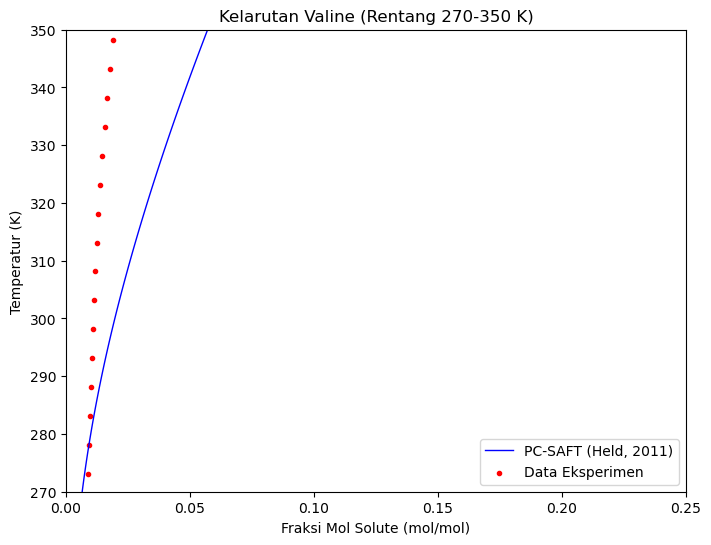

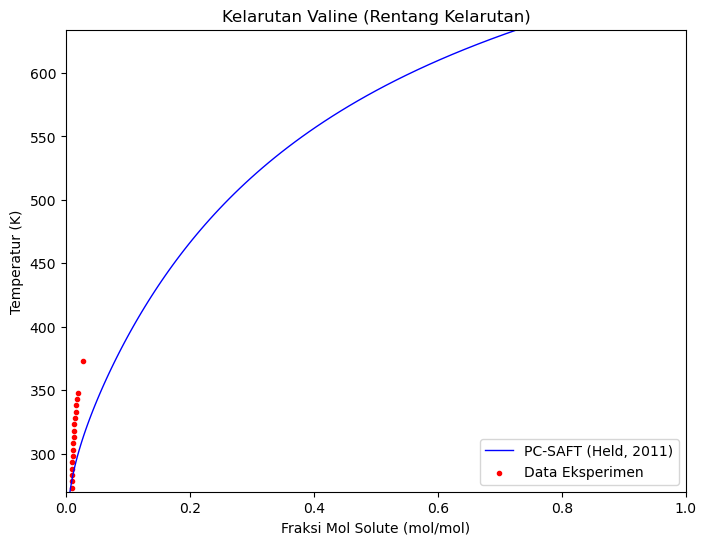

In [16]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_valine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["valine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model1.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["valine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, 634.138)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [33]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["valine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["valine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["valine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["valine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [6]:
aard_p   = calculate_AAD(model1, "sol_valine.csv", solubility_held)


=== AAD: sol_valine.csv ===


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.007551      16.8748 
278.1500    0.009341      0.009303      0.4107  
283.1500    0.009643      0.011295      17.1313 
288.1500    0.009990      0.013526      35.4017 
293.1500    0.010367      0.015991      54.2582 
298.1500    0.010788      0.018681      73.1574 
303.1500    0.011285      0.021583      91.2603 
308.1500    0.011811      0.024687      109.0208
313.1500    0.012411      0.027979      125.4381
318.1500    0.013071      0.031449      140.6088
323.1500    0.013819      0.035086      153.8933
328.1500    0.014656      0.038881      165.2826
333.1500    0.015567      0.042825      175.1081
338.1500    0.016594      0.046912      182.7023
343.1500    0.017738      0.051136      188.2843
348.1500    0.019028      0.055494      191.6515
373.1500    0.028120      0.079218      181.7145
AARD = 111.8940%


111.89404744731539

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [34]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
valine_gclow,117.15,7.10121,2.764402,294.2662,2,2
valine_gcmid,117.15,7.10121,2.764402,294.2662,2,2
valine_gcup,117.15,7.10121,2.764402,294.2662,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,valine_gclow,0.185853
water,valine_gcmid,0.185853
water,valine_gcup,0.185853
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
valine_gclow,H,valine_gclow,e,3230.895373,0.011536
valine_gcmid,H,valine_gcmid,e,3230.895373,0.011536 
valine_gcup,H,valine_gcup,e,3230.895373,0.011536
water,H,valine_gclow,e,2828.283,0.022783
water,e,valine_gclow,H,2828.283,0.022783
water,H,valine_gcmid,e,2828.283,0.022783
water,e,valine_gcmid,H,2828.283,0.022783
water,H,valine_gcup,e,2828.283,0.022783
water,e,valine_gcup,H,2828.283,0.022783
"""
components_low = ["water", "valine_gclow"]
components_mid = ["water", "valine_gcmid"]
components_up = ["water", "valine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 25051.0
Tm = 581.83
up bound
Hfus = 29159.36
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    8.66105e-13  1.48108e-13  3.61569e-14
   2 │      272.674  1.27688e-12  2.2409e-13   5.56968e-14
   3 │      275.348  1.86803e-12  3.36283e-13  8.50657e-14
   4 │      278.022  2.71253e-12  5.00648e-13  1.28848e-13
   5 │      280.695  3.91041e-12  7.39622e-13  1.93601e-13
   6 │      283.369  5.59784e-12  1.08452e-12  2.88634e-13
   7 │      286.043  7.95902e-12  1.57873e-12  4.2707e-13
   8 │      288.717  1.12415e-11  2.28202e-12  6.27274e-13
   9 │      291.391  1.57763e-11  3.2761e-12   9.14779e-13
  10 │      294.065  2.20027e-11  4.67207e-12  1.32484e-12
  11 │      296.738  3.05012e-11  6.61997e-12  1.90584e-12
  12 │      299.412  4.20342e-11  9.32134e-12  2.72375e-12
  13 │      302.086  5.75977e-11  1.30452e-11  3.86798e-12
  14 

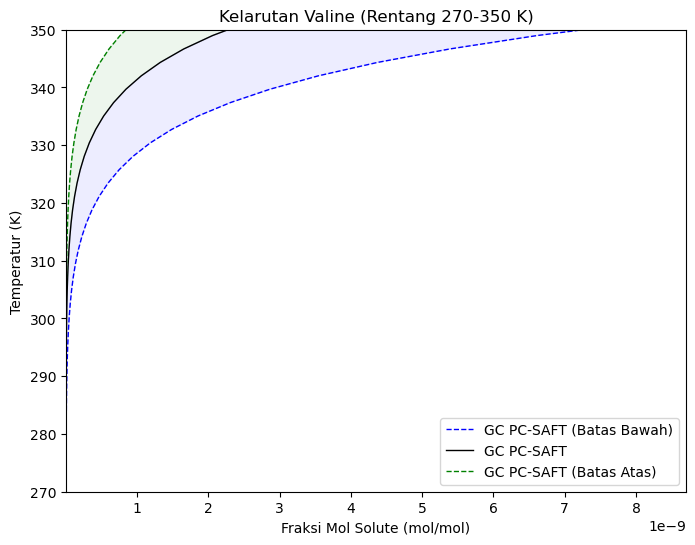

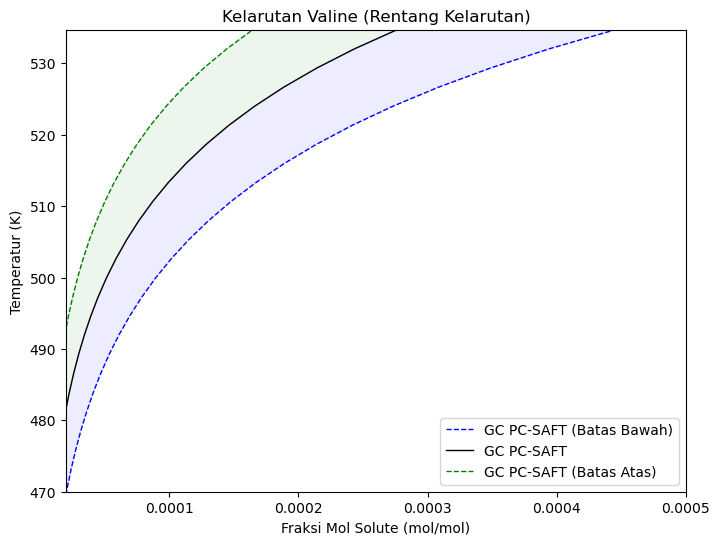

In [27]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_valine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(6.8e-15, 8.7e-9)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end


function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end


    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(2e-5, 0.0005)
    plt.ylim(470, model2_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [35]:
aard_p   = calculate_AAD(model2_low, "sol_valine.csv", solubility_gclow)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000000      100.0000
278.1500    0.009341      0.000000      100.0000
283.1500    0.009643      0.000000      100.0000
288.1500    0.009990      0.000000      100.0000
293.1500    0.010367      0.000000      100.0000
298.1500    0.010788      0.000000      100.0000
303.1500    0.011285      0.000000      100.0000
308.1500    0.011811      0.000000      100.0000
313.1500    0.012411      0.000000      100.0000
318.1500    0.013071      0.000000      100.0000
323.1500    0.013819      0.000000      100.0000
328.1500    0.014656      0.000000      100.0000
333.1500    0.015567      0.000000      100.0000
338.1500    0.016594      0.000000      100.0000
343.1500    0.017738      0.000000      100.0000
348.1500    0.019028      0.000000      100.0000
373.1500    0.028120      0.000000      99.9998 
AARD = 100.0000%


99.99998424325997

In [36]:
aard_p   = calculate_AAD(model2_mid, "sol_valine.csv", solubility_gcmid)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000000      100.0000
278.1500    0.009341      0.000000      100.0000
283.1500    0.009643      0.000000      100.0000
288.1500    0.009990      0.000000      100.0000
293.1500    0.010367      0.000000      100.0000
298.1500    0.010788      0.000000      100.0000
303.1500    0.011285      0.000000      100.0000
308.1500    0.011811      0.000000      100.0000
313.1500    0.012411      0.000000      100.0000
318.1500    0.013071      0.000000      100.0000
323.1500    0.013819      0.000000      100.0000
328.1500    0.014656      0.000000      100.0000
333.1500    0.015567      0.000000      100.0000
338.1500    0.016594      0.000000      100.0000
343.1500    0.017738      0.000000      100.0000
348.1500    0.019028      0.000000      100.0000
373.1500    0.028120      0.000000      99.9999 
AARD = 100.0000%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99999475455394

In [37]:
aard_p   = calculate_AAD(model2_up, "sol_valine.csv", solubility_gcup)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000000      100.0000
278.1500    0.009341      0.000000      100.0000
283.1500    0.009643      0.000000      100.0000
288.1500    0.009990      0.000000      100.0000
293.1500    0.010367      0.000000      100.0000
298.1500    0.010788      0.000000      100.0000
303.1500    0.011285      0.000000      100.0000
308.1500    0.011811      0.000000      100.0000
313.1500    0.012411      0.000000      100.0000
318.1500    0.013071      0.000000      100.0000
323.1500    0.013819      0.000000      100.0000
328.1500    0.014656      0.000000      100.0000
333.1500    0.015567      0.000000      100.0000
338.1500    0.016594      0.000000      100.0000
343.1500    0.017738      0.000000      100.0000
348.1500    0.019028      0.000000      100.0000
373.1500    0.028120      0.000000      100.0000
AARD = 100.0000%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99999795876646

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [19]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
valine_held,117.15,7.10121,2.764402,294.2662,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,valine_held,0.185853
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
valine_held,H,valine_held,e,3230.895373,0.011536
water,H,valine_held,e,2828.283,0.022783
water,e,valine_held,H,2828.283,0.022783
"""
components = ["water", "valine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[353.94 262.7470451790188; 262.7470451790188 294.2662]
[2.8014570000000003e-10 2.7829295e-10; 2.7829295e-10 2.764402e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2828.283, 2828.283, 3230.895373]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.022783, 0.022783, 0.011536]
kij = 0.18585300000000005
Hfus = 33677.52
Tm = 671.4



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          7.46121e-15
   2 │      274.055        1.47507e-14
   3 │      278.109        2.85778e-14
   4 │      282.164        5.43076e-14
   5 │      286.218        1.01316e-13
   6 │      290.273        1.85712e-13
   7 │      294.327        3.34714e-13
   8 │      298.382        5.93604e-13
   9 │      302.436        1.03658e-12
  10 │      306.491        1.78351e-12
  11 │      310.545        3.02538e-12
  12 │      314.6          5.06251e-12
  13 │      318.655        8.36128e-12
  14 │      322.709        1.36372e-11
  15 │      326.764        2.19757e-11
  16 │      330.818        3.50044e-11
  17 │      334.873        5.51395e-11
  18 │      338.927        8.59302e-11
  19 │      342.982        1.3254e-10
  20 │      347.036        2.02412e-10
  21 │      351.091        3.06175e-10
  22 │      3

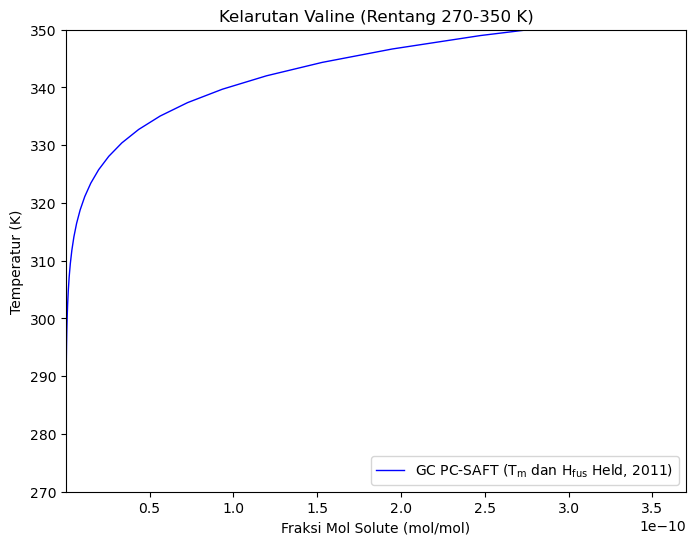

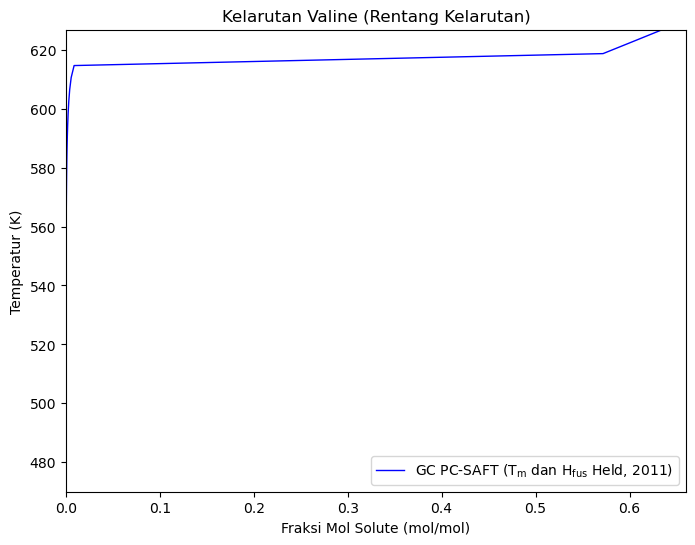

In [21]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_valine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["valine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(7.4e-15, 3.7e-10)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model3.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["valine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.66)
    plt.ylim(470.0, 626.8)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [22]:
aard_p   = calculate_AAD(model3, "sol_valine.csv", solubility_held)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000000      100.0000
278.1500    0.009341      0.000000      100.0000
283.1500    0.009643      0.000000      100.0000
288.1500    0.009990      0.000000      100.0000
293.1500    0.010367      0.000000      100.0000
298.1500    0.010788      0.000000      100.0000
303.1500    0.011285      0.000000      100.0000
308.1500    0.011811      0.000000      100.0000
313.1500    0.012411      0.000000      100.0000
318.1500    0.013071      0.000000      100.0000
323.1500    0.013819      0.000000      100.0000
328.1500    0.014656      0.000000      100.0000
333.1500    0.015567      0.000000      100.0000
338.1500    0.016594      0.000000      100.0000
343.1500    0.017738      0.000000      100.0000
348.1500    0.019028      0.000000      100.0000
373.1500    0.028120      0.000000      100.0000
AARD = 100.0000%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.9999992933425

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [38]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
valine_gclow,117.15,7.10121,2.764402,294.2662,2,2
valine_gcmid,117.15,7.10121,2.764402,294.2662,2,2
valine_gcup,117.15,7.10121,2.764402,294.2662,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,valine_gclow,-0.0757
water,valine_gcmid,-0.0757
water,valine_gcup,-0.0757
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
valine_gclow,H,valine_gclow,e,3230.895373,0.011536
valine_gcmid,H,valine_gcmid,e,3230.895373,0.011536 
valine_gcup,H,valine_gcup,e,3230.895373,0.011536
water,H,valine_gclow,e,2828.283,0.022783
water,e,valine_gclow,H,2828.283,0.022783
water,H,valine_gcmid,e,2828.283,0.022783
water,e,valine_gcmid,H,2828.283,0.022783
water,H,valine_gcup,e,2828.283,0.022783
water,e,valine_gcup,H,2828.283,0.022783
"""
components_low = ["water", "valine_gclow"]
components_mid = ["water", "valine_gcmid"]
components_up = ["water", "valine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 25051.0
Tm = 581.83
up bound
Hfus = 29159.36
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low     X_Mid      X_Up      
     │ Float64       Float64   Float64    Float64   
─────┼──────────────────────────────────────────────
   1 │      270.0    0.108118  0.0483993  0.0222283
   2 │      272.674  0.111651  0.050803   0.0238395
   3 │      275.348  0.115231  0.0532501  0.0255003
   4 │      278.022  0.118857  0.0557404  0.0272095
   5 │      280.695  0.122531  0.0582737  0.0289661
   6 │      283.369  0.126254  0.0608501  0.030769
   7 │      286.043  0.130027  0.0634696  0.0326175
   8 │      288.717  0.13385   0.0661322  0.0345107
   9 │      291.391  0.137725  0.0688383  0.0364479
  10 │      294.065  0.141654  0.0715878  0.0384285
  11 │      296.738  0.145636  0.0743813  0.040452
  12 │      299.412  0.149673  0.077219   0.0425179
  13 │      302.086  0.153767  0.0801012  0.0446259
  14 │      304.76   0.157919  0.0830285  0.0467756
  15 │      307.434  0.162129  0.0860013  0.0489669
  16 │      31

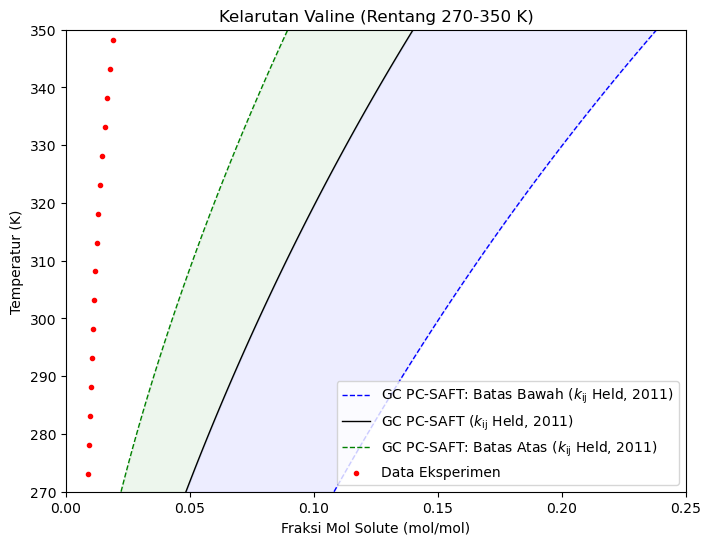

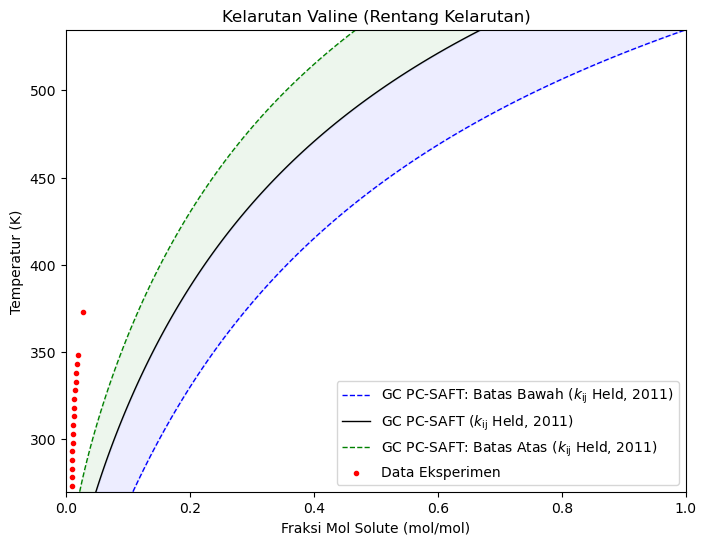

In [29]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_valine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [39]:
aard_p   = calculate_AAD(model4_low, "sol_valine.csv", solubility_gclow)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.112285      1136.0260
278.1500    0.009341      0.119033      1174.2911
283.1500    0.009643      0.125947      1206.1111
288.1500    0.009990      0.133035      1231.7139
293.1500    0.010367      0.140304      1253.4314
298.1500    0.010788      0.147760      1269.6521
303.1500    0.011285      0.155412      1277.2008
308.1500    0.011811      0.163267      1282.3710
313.1500    0.012411      0.171333      1280.4825
318.1500    0.013071      0.179620      1274.2075
323.1500    0.013819      0.188135      1261.3919
328.1500    0.014656      0.196890      1243.3732
333.1500    0.015567      0.205893      1222.6645
338.1500    0.016594      0.215155      1196.5826
343.1500    0.017738      0.224688      1166.6930
348.1500    0.019028      0.234501      1132.4268
373.1500    0.028120      0.288231      925.0060
AARD = 1207.8603%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


1207.8603227245976

In [40]:
aard_p   = calculate_AAD(model4_mid, "sol_valine.csv", solubility_gcmid)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.051236      463.9967
278.1500    0.009341      0.055861      498.0156
283.1500    0.009643      0.060637      528.8279
288.1500    0.009990      0.065564      556.3122
293.1500    0.010367      0.070643      581.4470
298.1500    0.010788      0.075874      603.3062
303.1500    0.011285      0.081261      620.0995
308.1500    0.011811      0.086805      634.9767
313.1500    0.012411      0.092512      645.3959
318.1500    0.013071      0.098384      652.7005
323.1500    0.013819      0.104426      655.6489
328.1500    0.014656      0.110642      654.9093
333.1500    0.015567      0.117039      651.8643
338.1500    0.016594      0.123622      644.9792
343.1500    0.017738      0.130397      635.1241
348.1500    0.019028      0.137371      621.9586
373.1500    0.028120      0.175498      524.1042
AARD = 598.4510%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


598.450981966841

In [41]:
aard_p   = calculate_AAD(model4_up, "sol_valine.csv", solubility_gcup)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.024132      165.6389
278.1500    0.009341      0.027293      192.1807
283.1500    0.009643      0.030620      217.5342
288.1500    0.009990      0.034106      241.4053
293.1500    0.010367      0.037746      264.1159
298.1500    0.010788      0.041537      285.0272
303.1500    0.011285      0.045476      302.9929
308.1500    0.011811      0.049561      319.6290
313.1500    0.012411      0.053790      333.4024
318.1500    0.013071      0.058163      344.9876
323.1500    0.013819      0.062681      353.5748
328.1500    0.014656      0.067344      359.4860
333.1500    0.015567      0.072154      363.5177
338.1500    0.016594      0.077112      364.6968
343.1500    0.017738      0.082221      363.5288
348.1500    0.019028      0.087485      359.7780
373.1500    0.028120      0.116245      313.3901
AARD = 302.6404%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


302.64038507242395

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [42]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
valine_gclow,117.15,7.10121,2.764402,294.2662,2,2
valine_gcmid,117.15,7.10121,2.764402,294.2662,2,2
valine_gcup,117.15,7.10121,2.764402,294.2662,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,valine_gclow,0
water,valine_gcmid,0
water,valine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
valine_gclow,H,valine_gclow,e,3230.895373,0.011536
valine_gcmid,H,valine_gcmid,e,3230.895373,0.011536 
valine_gcup,H,valine_gcup,e,3230.895373,0.011536
water,H,valine_gclow,e,2828.283,0.022783
water,e,valine_gclow,H,2828.283,0.022783
water,H,valine_gcmid,e,2828.283,0.022783
water,e,valine_gcmid,H,2828.283,0.022783
water,H,valine_gcup,e,2828.283,0.022783
water,e,valine_gcup,H,2828.283,0.022783
"""
components_low = ["water", "valine_gclow"]
components_mid = ["water", "valine_gcmid"]
components_up = ["water", "valine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 25051.0
Tm = 581.83
up bound
Hfus = 29159.36
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
30×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    0.000340975  5.7287e-5    1.39474e-5
   2 │      279.128  0.000592088  0.000107301  2.76799e-5
   3 │      288.256  0.000998989  0.00019319   5.2544e-5
   4 │      297.384  0.00164864   0.000335994  9.58574e-5
   5 │      306.512  0.00268146   0.00056711   0.000168784
   6 │      315.64   0.00434001   0.000933253  0.000287979
   7 │      324.768  0.00709001   0.00150455   0.000477902
   8 │      333.895  0.0119872    0.00238874   0.0007742
   9 │      343.023  0.0221746    0.00375806   0.00122886
  10 │      352.151  0.0501117    0.00590466   0.00191851
  11 │      361.279  0.100175     0.0093663    0.00295855
  12 │      370.407  0.144828     0.0152394    0.00452854
  13 │      379.535  0.184733     0.0259547    0.00692041
  14 │      388.6

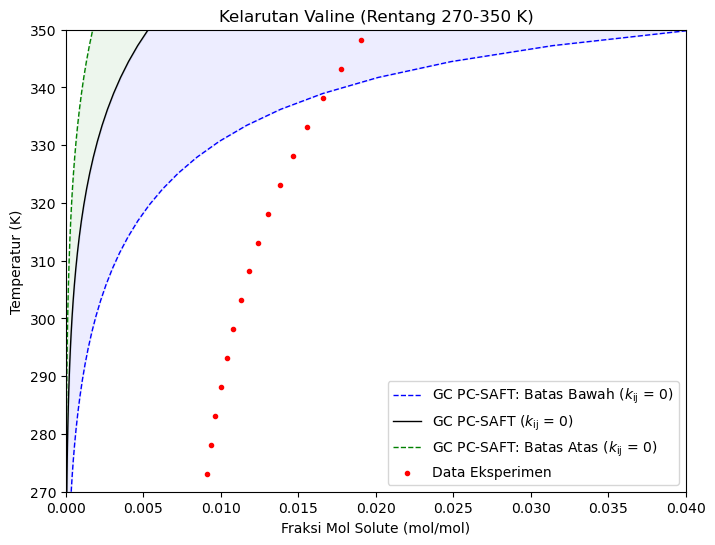

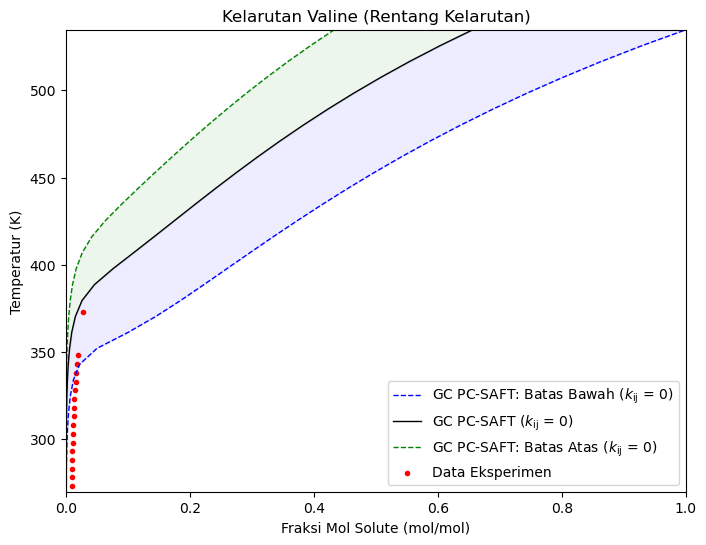

In [43]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_valine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 30)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.04)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 30)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model5_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [44]:
aard_p   = calculate_AAD(model5_low, "sol_valine.csv", solubility_gclow)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000414      95.4426 
278.1500    0.009341      0.000559      94.0165 
283.1500    0.009643      0.000748      92.2437 
288.1500    0.009990      0.000993      90.0590 
293.1500    0.010367      0.001310      87.3649 
298.1500    0.010788      0.001718      84.0741 
303.1500    0.011285      0.002244      80.1124 
308.1500    0.011811      0.002924      75.2461 
313.1500    0.012411      0.003805      69.3412 
318.1500    0.013071      0.004959      62.0623 
323.1500    0.013819      0.006489      53.0422 
328.1500    0.014656      0.008562      41.5816 
333.1500    0.015567      0.011458      26.3941 
338.1500    0.016594      0.015701      5.3841  
343.1500    0.017738      0.022390      26.2264 
348.1500    0.019028      0.034084      79.1304 
373.1500    0.028120      0.157159      458.8869
AARD = 89.4476%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


89.4475530499137

In [45]:
aard_p   = calculate_AAD(model5_mid, "sol_valine.csv", solubility_gcmid)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000071      99.2131 
278.1500    0.009341      0.000101      98.9239 
283.1500    0.009643      0.000140      98.5515 
288.1500    0.009990      0.000192      98.0789 
293.1500    0.010367      0.000261      97.4826 
298.1500    0.010788      0.000351      96.7421 
303.1500    0.011285      0.000469      95.8424 
308.1500    0.011811      0.000621      94.7402 
313.1500    0.012411      0.000817      93.4210 
318.1500    0.013071      0.001066      91.8429 
323.1500    0.013819      0.001384      89.9834 
328.1500    0.014656      0.001788      87.7983 
333.1500    0.015567      0.002301      85.2167 
338.1500    0.016594      0.002953      82.2069 
343.1500    0.017738      0.003782      78.6807 
348.1500    0.019028      0.004842      74.5552 
373.1500    0.028120      0.017783      36.7612 
AARD = 88.2377%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


88.23770252012005

In [46]:
aard_p   = calculate_AAD(model5_up, "sol_valine.csv", solubility_gcup)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000018      99.8045 
278.1500    0.009341      0.000026      99.7240 
283.1500    0.009643      0.000037      99.6173 
288.1500    0.009990      0.000052      99.4778 
293.1500    0.010367      0.000073      99.2971 
298.1500    0.010788      0.000101      99.0670 
303.1500    0.011285      0.000138      98.7809 
308.1500    0.011811      0.000186      98.4236 
313.1500    0.012411      0.000250      97.9885 
318.1500    0.013071      0.000332      97.4608 
323.1500    0.013819      0.000438      96.8328 
328.1500    0.014656      0.000573      96.0908 
333.1500    0.015567      0.000745      95.2147 
338.1500    0.016594      0.000962      94.2000 
343.1500    0.017738      0.001237      93.0285 
348.1500    0.019028      0.001581      91.6910 
373.1500    0.028120      0.005143      81.7092 
AARD = 96.3770%


96.37697966274645

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [47]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
valine_gclow,117.15,7.10121,2.764402,294.2662,2,2
valine_gcmid,117.15,7.10121,2.764402,294.2662,2,2
valine_gcup,117.15,7.10121,2.764402,294.2662,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,valine_gclow,0.217142102
water,valine_gcmid,0.217142102
water,valine_gcup,0.217142102
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
valine_gclow,H,valine_gclow,e,3230.895373,0.011536
valine_gcmid,H,valine_gcmid,e,3230.895373,0.011536 
valine_gcup,H,valine_gcup,e,3230.895373,0.011536
water,H,valine_gclow,e,2828.283,0.022783
water,e,valine_gclow,H,2828.283,0.022783
water,H,valine_gcmid,e,2828.283,0.022783
water,e,valine_gcmid,H,2828.283,0.022783
water,H,valine_gcup,e,2828.283,0.022783
water,e,valine_gcup,H,2828.283,0.022783
"""
components_low = ["water", "valine_gclow"]
components_mid = ["water", "valine_gcmid"]
components_up = ["water", "valine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 25051.0
Tm = 581.83
up bound
Hfus = 29159.36
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    3.14676e-14  5.38109e-15  1.31366e-15
   2 │      272.674  4.81879e-14  8.45692e-15  2.10193e-15
   3 │      275.348  7.31726e-14  1.31726e-14  3.33212e-15
   4 │      278.022  1.10206e-13  2.03406e-14  5.23491e-15
   5 │      280.695  1.64672e-13  3.11463e-14  8.15275e-15
   6 │      283.369  2.44169e-13  4.73049e-14  1.25898e-14
   7 │      286.043  3.59351e-13  7.12801e-14  1.92823e-14
   8 │      288.717  5.25048e-13  1.06584e-13  2.92975e-14
   9 │      291.391  7.6177e-13   1.58189e-13  4.41708e-14
  10 │      294.065  1.09769e-12  2.33085e-13  6.6095e-14
  11 │      296.738  1.57128e-12  3.41031e-13  9.81803e-14
  12 │      299.412  2.23474e-12  4.95568e-13  1.44808e-13
  13 │      302.086  3.15848e-12  7.15361e-13  2.12108e-13
  14 

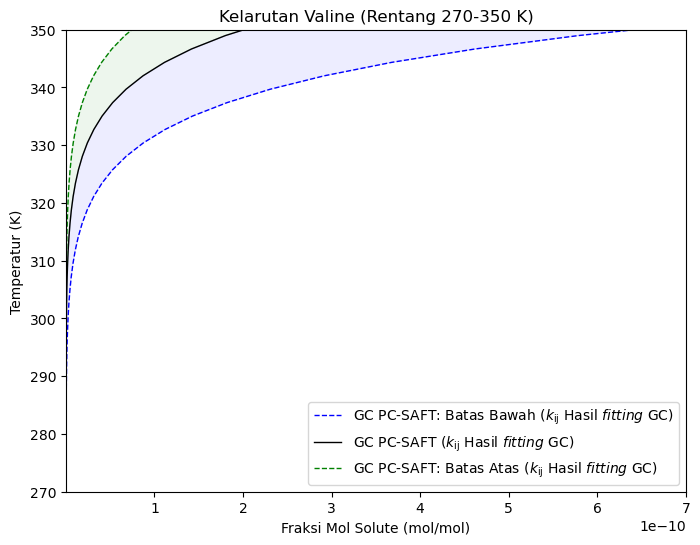

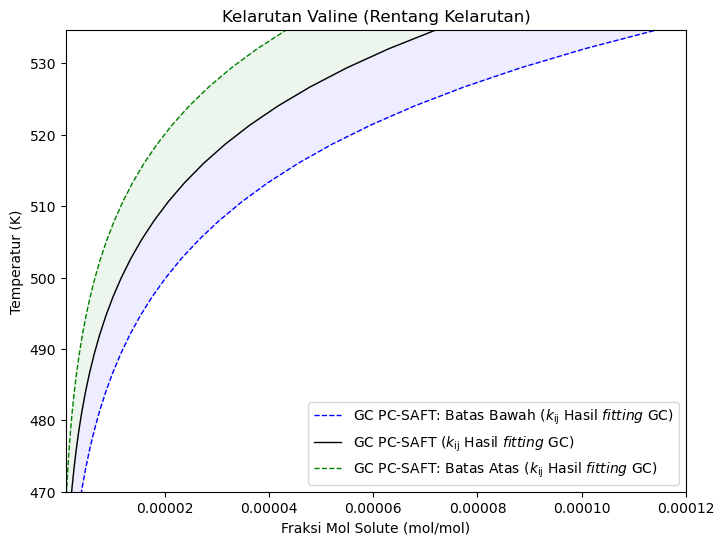

In [49]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_valine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(1e-14, 7e-10)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["valine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["valine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["valine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Valine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(1e-6, 0.00012)
    plt.ylim(470.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_valine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [50]:
aard_p   = calculate_AAD(model6_low, "sol_valine.csv", solubility_gclow)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000000      100.0000
278.1500    0.009341      0.000000      100.0000
283.1500    0.009643      0.000000      100.0000
288.1500    0.009990      0.000000      100.0000
293.1500    0.010367      0.000000      100.0000
298.1500    0.010788      0.000000      100.0000
303.1500    0.011285      0.000000      100.0000
308.1500    0.011811      0.000000      100.0000
313.1500    0.012411      0.000000      100.0000
318.1500    0.013071      0.000000      100.0000
323.1500    0.013819      0.000000      100.0000
328.1500    0.014656      0.000000      100.0000
333.1500    0.015567      0.000000      100.0000
338.1500    0.016594      0.000000      100.0000
343.1500    0.017738      0.000000      100.0000
348.1500    0.019028      0.000000      100.0000
373.1500    0.028120      0.000000      100.0000
AARD = 100.0000%


99.99999846995429

In [51]:
aard_p   = calculate_AAD(model6_mid, "sol_valine.csv", solubility_gcmid)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000000      100.0000
278.1500    0.009341      0.000000      100.0000
283.1500    0.009643      0.000000      100.0000
288.1500    0.009990      0.000000      100.0000
293.1500    0.010367      0.000000      100.0000
298.1500    0.010788      0.000000      100.0000
303.1500    0.011285      0.000000      100.0000
308.1500    0.011811      0.000000      100.0000
313.1500    0.012411      0.000000      100.0000
318.1500    0.013071      0.000000      100.0000
323.1500    0.013819      0.000000      100.0000
328.1500    0.014656      0.000000      100.0000
333.1500    0.015567      0.000000      100.0000
338.1500    0.016594      0.000000      100.0000
343.1500    0.017738      0.000000      100.0000
348.1500    0.019028      0.000000      100.0000
373.1500    0.028120      0.000000      100.0000
AARD = 100.0000%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99999948386856

In [52]:
aard_p   = calculate_AAD(model6_up, "sol_valine.csv", solubility_gcup)


=== AAD: sol_valine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.009084      0.000000      100.0000
278.1500    0.009341      0.000000      100.0000
283.1500    0.009643      0.000000      100.0000
288.1500    0.009990      0.000000      100.0000
293.1500    0.010367      0.000000      100.0000
298.1500    0.010788      0.000000      100.0000
303.1500    0.011285      0.000000      100.0000
308.1500    0.011811      0.000000      100.0000
313.1500    0.012411      0.000000      100.0000
318.1500    0.013071      0.000000      100.0000
323.1500    0.013819      0.000000      100.0000
328.1500    0.014656      0.000000      100.0000
333.1500    0.015567      0.000000      100.0000
338.1500    0.016594      0.000000      100.0000
343.1500    0.017738      0.000000      100.0000
348.1500    0.019028      0.000000      100.0000
373.1500    0.028120      0.000000      100.0000
AARD = 100.0000%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99999979751061